In [2]:
# Import Libraries
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=all logs, 1=filter INFO, 2=filter WARNING, 3=filter ERROR
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

2025-10-08 11:08:19.422722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759900099.570872    9991 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759900099.615873    9991 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759900099.863841    9991 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759900099.863902    9991 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759900099.863909    9991 computation_placer.cc:177] computation placer alr

In [3]:
# Parameters
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 32
EPOCHS = 20

In [4]:
# Data Preparation
X, y, class_names = [], [], []
class_map = {}

print("[INFO] Loading dataset...")

for shape_name in os.listdir(DATA_PATH):  # e.g., Circle, Square, Triangle
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path):  # e.g., 0, 1, 2, ...
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.endswith(".png") or file.endswith(".jpg"):
                path = os.path.join(score_path, file)
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
X = np.expand_dims(X, -1)   # shape = (N,128,128,1)
y = np.array(y)
y_cat = to_categorical(y, num_classes=len(class_map))

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4297 samples, 34 classes


In [5]:
# Train/test split
print("[INFO] Splitting dataset...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)
print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")

[INFO] Splitting dataset...
[INFO] Train: (3437, 128, 128, 1), Test: (860, 128, 128, 1)


In [6]:
print("[INFO] Classes:", class_names)

[INFO] Classes: ['Triangle_0', 'Triangle_4', 'Triangle_5', 'Star_3', 'Star_2', 'Star_0', 'Star_4', 'Star_5', 'Wave_3', 'Wave_2', 'Wave_0', 'Wave_4', 'Circle_3', 'Circle_2', 'Circle_0', 'Circle_4', 'Square_0', 'Square_4', 'Square_5', 'Overlapped pencils_3', 'Overlapped pencils_2', 'Overlapped pencils_0', 'Overlapped pencils_4', 'Overlapped pencils_6', 'Overlapped pencils_5', 'Overlapped circle_2', 'Overlapped circle_0', 'Overlapped circle_4', 'Overlapped circle_6', 'Overlapped circle_5', 'Diagonal_3', 'Diagonal_0', 'Diagonal_4', 'Diagonal_5']


In [7]:
# Global CNN Model/ model build
base = EfficientNetB0(include_top=False, input_shape=(128,128,1), weights=None)

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_map), activation="softmax")
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

print(model.summary())

2025-10-08 11:09:37.765248: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,048,991 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 34)             │        43,554 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,092,545 (15.61 MB)

 Trainable params: 4,050,526 (15.45 MB)

 Non-trainable params: 42,019 (164.14 KB)

None


In [8]:
# Training
print("[INFO] Training model...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

[INFO] Training model...
Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.1449 - loss: 3.0943 - val_accuracy: 0.1163 - val_loss: 3.0167
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.4332 - loss: 2.0005 - val_accuracy: 0.0828 - val_loss: 3.2441
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.6287 - loss: 1.2588 - val_accuracy: 0.0945 - val_loss: 3.2941
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.7112 - loss: 0.8783 - val_accuracy: 0.1163 - val_loss: 3.5324
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.7473 - loss: 0.7214 - val_accuracy: 0.1163 - val_loss: 3.7191
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7882 - loss: 0.6136 - val_accuracy: 0.1890 - val_loss: 3.2342
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8298 - loss: 0.4813 - val_accuracy: 0.1628 - val_loss: 3.4723
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.8607 - loss: 0.4386 -

In [27]:
# Evaluation
print("[INFO] Evaluating model...")
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

[INFO] Evaluating model...
Test Accuracy: 0.5884


In [31]:
# Predict on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print classification report safely
print("\nClassification Report:")
print(classification_report(
    y_true, y_pred_classes,
    labels=np.arange(len(class_map)),
    target_names=class_names,
    zero_division=0
))

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         8
           2       0.90      0.76      0.83       119
           3       0.23      0.26      0.24        19
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.53      0.52      0.53        50
           7       0.25      0.04      0.07        24
           8       0.10      0.05      0.06        22
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         0
          11       0.73      0.83      0.78       103
          12       0.22      0.13      0.17        15
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         0
          15       0.81      0.57      0.67        91
          16    

In [24]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))


Confusion Matrix:
[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0]
 [ 0  0  7  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0]
 [ 1  3 91  1  0  0  2  0  0  1  8  0  0  0  1  0  0  0  0  1  4  0  0  0
   2  1  0  3]
 [ 0  0  0  5  0  0  3  0  0  0  1  0  0  0  0  0  0  0  0  0  2  0  0  0
   6  1  0  1]
 [ 0  0  0  1  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   3  0  0  0]
 [ 0  0  0  8  2  0 26  2  0  0  0  0  0  0  0  0  0  0  0  1  1  1  0  0
   7  1  0  1]
 [ 0  0  0  2  0  0 13  1  0  0  1  0  1  0  0  0  0  0  0  1  0  0  0  0
   4  1  0  0]
 [ 0  0  0  0  0  0  0  0  1  0 16  0  0  0  0  0  0  0  0  3  0  0  0  0
   1  1  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0
   0  1  0  0]
 [ 0  0  2  0  0  0  0  1  5  0 86  0  0  0  0  0  0  0  0  2  0  0  0  0
   6  1  0  0]
 [

In [13]:
# Prediction Helper
def decode_prediction(pred_idx):
    return class_names[pred_idx]

In [14]:
# Plot training & validation accuracy/loss
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

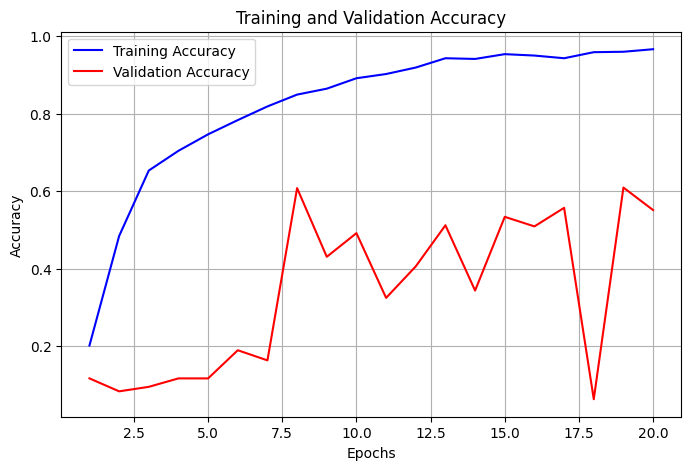

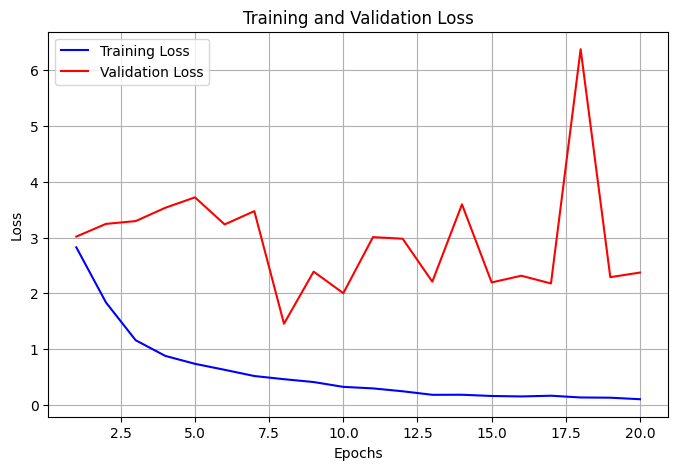

In [15]:
# Call after training
plot_training(history)

In [32]:
# Save directory
SAVE_DIR = "./model_outputs/efficientnet"
os.makedirs(SAVE_DIR, exist_ok=True)

In [33]:
# Save
pd.DataFrame(history.history).to_csv(os.path.join(SAVE_DIR, "global_efficientnet_training_history.csv"), index=False)

In [34]:
# Save Model
model.save(os.path.join(SAVE_DIR, "efficientnet_bot2_model.h5"))
print("[INFO] Model saved as global_cnn_model.h5")

[INFO] Model saved as global_cnn_model.h5


In [35]:
# Save training history as JSON
with open(os.path.join(SAVE_DIR, "training_history_efficientnet.json"), "w") as f:
    json.dump(history.history, f)
print("[INFO] Training history saved as JSON")

[INFO] Training history saved as JSON


In [36]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [37]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()

In [45]:
# Convert to DataFrame
report_dict = classification_report(
    y_true, 
    y_pred_classes,
    labels=np.arange(len(class_map)),
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

# Save Classification report
report_path = os.path.join(SAVE_DIR, "efficientnet_classification_report.csv")
report_df.to_csv(report_path, index=True)

print("[INFO] Save Classification report as CSV")

[INFO] Save Classification report as CSV
